**420-C74-SF - Techniques d'apprentissage automatique - Automne 2026 - Spécialiste en solutions d'intelligence artificielle**<br/>
© 2026 MKL.AI - Tous droits réservés
<br/>
![Atelier - Validation croisée](static/11-banner.png)
<br/>
**Objectif:** cette séance de travaux pratiques a pour objectif la mise en oeuvre de la validation croisée à k plis à l'aide de la librairie **scikit-learn**. Les modèles et algorithmes utilisés seront la régression logistique et la classification KNN Le jeu de données sera de nouveau **Heart**

In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

## 0 - Chargement des bibliothèques

In [1]:
# Manipulation de données
import numpy as np
import pandas as pd

# Visualisation de données
import matplotlib.pyplot as plt
import seaborn as sns

# Helpers
from helpers import polynomial

# Outils divers
from tqdm import tqdm
from collections import defaultdict

# Machine Learning
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [3]:
# Configuration de la visualisation
sns.set(style="darkgrid", rc={'figure.figsize':(12,6)})
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})

## 1 - Lecture du jeu de données

<strong style="color: #4a86e8">Exercice 1-1: lire le fichier `Heart.csv`<strong/>

In [4]:
# Compléter le code ci-dessous ~ 1-2 lignes

HRT = pd.read_csv('../../data/Heart.csv', index_col=0)

In [5]:
# On supprime tout de suite les données manquantes. Ceci sera vu plus en détail plus tard dans le cours
HRT = HRT.dropna()

<strong style="color: #4a86e8">Exercice 1-2: afficher les dix premières lignes de la trame de données HRT</strong>

In [6]:
# Compléter le code ci-dessous ~ 1 ligne

HRT.head(10)

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
6,56,1,nontypical,120,236,0,0,178,0,0.8,1,0.0,normal,No
7,62,0,asymptomatic,140,268,0,2,160,0,3.6,3,2.0,normal,Yes
8,57,0,asymptomatic,120,354,0,0,163,1,0.6,1,0.0,normal,No
9,63,1,asymptomatic,130,254,0,2,147,0,1.4,2,1.0,reversable,Yes
10,53,1,asymptomatic,140,203,1,2,155,1,3.1,3,0.0,reversable,Yes


## 2 - Préparation de données

Nous allons considérer l'ensemble des variables explicatives du jeu de données **Heart**

<strong style="color: #4a86e8">Exercice 2-1: Encoder les variables explicatives catégorielles. Utiliser le numpy array `X` pour stocker les variables explicatives et le vecteur `y` pour la variable réponse. Indice: utilisez pandas ;-)</strong>

In [7]:
# Compléter le code ci-dessous ~ 2-3 lignes

# Variables explicatives à k niveaux => k-1 variables indicatrices (drop_first=True)
X = pd.get_dummies(HRT.drop(['AHD'], axis=1), drop_first=True, dtype=int).values
# Variable réponse binaire => 0 / 1
y = HRT['AHD'].map({'No': 0, 'Yes': 1}).values

<strong style="color: #4a86e8">Exercice 2-1: Quel est le nombre de variables explicatives contenues dans `X` ?</strong>

In [8]:
# Compléter le code ci-dessous ~ 1 ligne

X.shape[1]

16

<strong style="color: #4a86e8">Exercice 2-2: Quel est le nombre d'observations ?</strong>

In [9]:
# Compléter le code ci-dessous ~ 1 ligne

X.shape[0]

297

## 3 - Validation croisée à 5 plis - Régression logistique

### 3 - 1 - Mélange des données et séparation en jeu d’entraînement et de test

<strong style="color: #4a86e8">Exercice 3-1: à l'aide de scikit-learn, sépararer les données en jeu d'entraînement et jeu de test. La taille du jeu de test doit représenter 30% de la taille du jeu de données et l'état du générateur aléatoire sera fixé à 2020 afin de permettre la reproductibilité</strong>

![3 - 1 - Mélange des données et séparation en jeu d’entraînement et de test](static/fig1.png)

In [10]:
# Compléter le code ci-dessous ~ 1 ligne
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=2020)

Vérification des dimensions de `X_train` et `X_test`

In [11]:
print(X_train.shape)
print(X_test.shape)

(207, 16)
(90, 16)


### 3 - 2 - Entraînement de plusieurs modèles de flexibilités différentes sur 5 plis de validation

<strong style="color: #4a86e8">Exercice 3-2: réaliser une validation croisée à 5-plis sur une régression logistique polynomiale (sans variables d'interaction) en faisant varier l'ordre `n` du polynôme de 1 à 5. Vous pouvez utiliser la fonction `polynomial` disponible dans `helpers.py`. Enregistrez dans le dictionnaire `history` les scores (accuracy) sur les jeux d'entraînement et de validation pour chaque valeurs de `n`</strong><br/><br/>

<strong style="color: green">Afin de faciliter l'écriture du code, cet exercice sera réalisé en deux étapes
<ul>
    <li>Etape 1: effectuer une validation croisée à 5 plis sur une régression logistique d'ordre 1 seulement</li>
    <li>Etape 2: inclure le code précédent dans une boucle for en faisant varier l'ordre de 1 à 5</li>
</ul>
<strong>

Instanciation de `scaler` pour la standardisation des données

In [14]:
scaler = StandardScaler()

### Etape 1 : effectuer une validation croisée à 5 plis sur une régression logistique d'ordre 1 seulement

![3 - 2 - Entraînement de plusieurs modèles de flexibilités différentes sur k plis de validation](static/fig2.png)

[sklearn.model_selection.KFold(n_splits=5, shuffle=False, random_state=None)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)

In [15]:
X_train_poly = polynomial(X_train, degree=1)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_train_scaled

array([[ 0.        , -2.12690643, -1.62221421, ..., -0.3086067 ,
         0.92998111, -0.83469834],
       [ 0.        ,  0.64138853,  0.6164414 , ..., -0.3086067 ,
         0.92998111, -0.83469834],
       [ 0.        , -1.01958845,  0.6164414 , ...,  3.24037035,
        -1.07529066,  1.19803761],
       ...,
       [ 0.        ,  0.86285213,  0.6164414 , ..., -0.3086067 ,
        -1.07529066,  1.19803761],
       [ 0.        , -0.46592945, -1.62221421, ..., -0.3086067 ,
         0.92998111, -0.83469834],
       [ 0.        ,  1.19504753,  0.6164414 , ..., -0.3086067 ,
        -1.07529066,  1.19803761]], shape=(207, 17))

In [16]:
# Compléter le code ci-dessous ~ 10-20 lignes ...

history = defaultdict(list)

# Instancier KFold (sklearn)
kf = KFold(n_splits=5, shuffle=True, random_state=2020)

# Ajouter x0 sur X (polynôme d'ordre 1)
X_train_poly = polynomial(X_train, degree=1)

# Stan4ardiser X (le scaler est ajusté sur le jeu d'entraînement seulement)
X_train_scaled = scaler.fit_transform(X_train_poly) # .fit().transform()

# Itérer sur les k plis
for train_index, val_index in kf.split(X_train_scaled):
    X_tr, X_val = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_val = y_train[train_index], y_train[val_index]

    # Effectuer la classification sur le plis courant (jeu d'entraînement)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr, y_tr)

    # Évaluer les performances sur le plis de validation
    history['train'].append(accuracy_score(y_tr, clf.predict(X_tr)))
    history['val'].append(accuracy_score(y_val, clf.predict(X_val)))

print(f"Accuracy de validation = {np.mean(history['val'])}")
print(f"Accuracy d'entraînement = {np.mean(history['train'])}")

Accuracy de validation = 0.8110336817653889
Accuracy d'entraînement = 0.8840379700620664


### Etape 2 - inclure le code précédent dans une boucle for en faisant varier l'ordre de 1 à 5

![3 - 2 - Entraînement de plusieurs modèles de flexibilités différentes sur k plis de validation](static/fig3.png)

In [17]:
# Compléter le code ci-dessous ~ quelques lignes ...

def LogisticRegressionCV(X_train_scaled, y_train, n_splits=5):
    history = defaultdict(list)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=2020)
    for train_index, val_index in kf.split(X_train_scaled):
        X_tr, X_val = X_train_scaled[train_index], X_train_scaled[val_index]
        y_tr, y_val = y_train[train_index], y_train[val_index]
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_tr, y_tr)
        history['train'].append(accuracy_score(y_tr, clf.predict(X_tr)))
        history['val'].append(accuracy_score(y_val, clf.predict(X_val)))
    return np.mean(history['train']), np.mean(history['val'])

history = defaultdict(list)
for n in range(1, 10):
    X_train_scaled = scaler.fit_transform(polynomial(X_train, degree=n))
    acc_train, acc_val = LogisticRegressionCV(X_train_scaled, y_train)
    history['train'].append(acc_train)
    history['val'].append(acc_val)

### 3 - 3 - Choix du meilleur modèle en fonction des performances sur les plis de validation

![3 - 3 - Choix du meilleur modèle en fonction des performances sur les plis de validation](static/fig4.png)

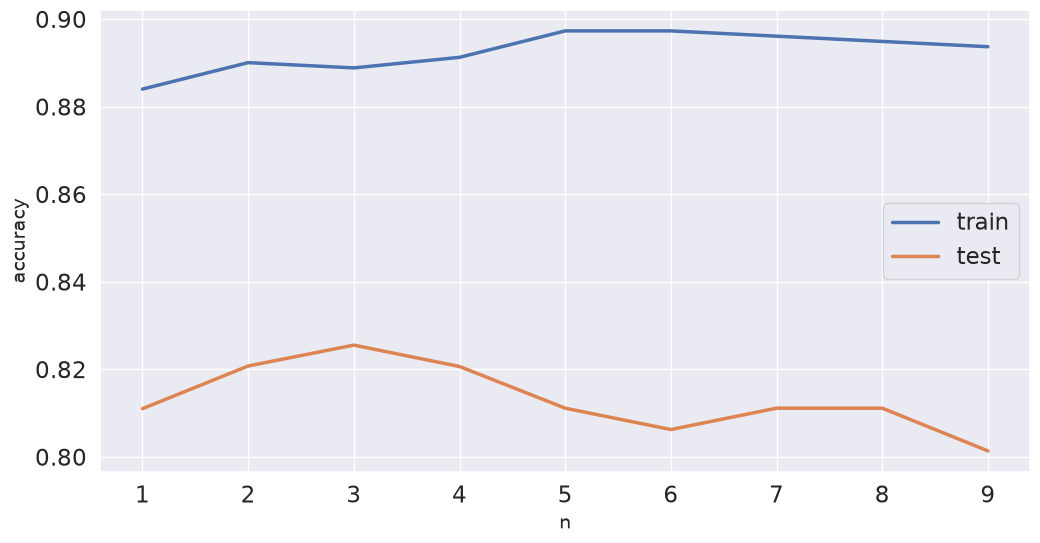

In [18]:
f, ax = plt.subplots(1,1)
ax.plot(range(1,10), history['train'], label="train")
ax.plot(range(1,10), history['val'], label="test")
ax.set_xlabel('n', fontsize=14)
ax.set_ylabel('accuracy', fontsize=14)
ax.legend()

### 3 - 4 - Entrainement du meilleur modèle

<strong style="color: #4a86e8">Exercice 3-4 : utiliser les résultas précédents pour sélectionner le meilleur modèle, et réentrainer ce modèle sur l'ensemble des données d'entraînement</strong>

![3 - 4 - Entrainement du meilleur modèle](static/fig5.png)

In [19]:
# Compléter la fonction ci-dessous ~ quelques lignes ...

# Meilleur modèle = ordre n ayant la meilleure accuracy moyenne sur les plis de validation
n_best = int(np.argmax(history['val'])) + 1
print(f"Meilleur ordre n = {n_best}")

# Réentraînement sur l'ensemble du jeu d'entraînement
X_train_scaled = scaler.fit_transform(polynomial(X_train, degree=n_best))
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

Meilleur ordre n = 3


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### 3 - 5 - Performances du meilleur modèle

<strong style="color: #4a86e8">Exercice 3-5 : Évaluer les performances du meilleur modèle sur le jeu de test</strong>
![3 - 5 - Performances du modèle final](static/fig6.png)

In [20]:
# Compléter la fonction ci-dessous ~ quelques lignes ...

# On applique au jeu de test le scaler ajusté sur le jeu d'entraînement
X_test_scaled = scaler.transform(polynomial(X_test, degree=n_best))
print(f"Accuracy d'entraînement = {accuracy_score(y_train, clf.predict(X_train_scaled))}")
print(f"Accuracy de test = {accuracy_score(y_test, clf.predict(X_test_scaled))}")

Accuracy d'entraînement = 0.8888888888888888
Accuracy de test = 0.8333333333333334


## 4 - Validation croisée à 5 plis - Algorithme des k plus proches voisins

### 4 - 1 - Mélange des données et séparation en jeu d’entraînement et de test

Vous pouvez reprendre `X_train`, `X_test`, `y_train` et `y_test` obtenus au **3-1**

### 4 - 2 - Entraînement de plusieurs modèles de flexibilités différentes sur 5 plis de validation

<strong style="color: #4a86e8">Exercice 4-2: réaliser une validation croisée à k-plis sur une classification KNN en faisant varier le nombre de voisins `k` de 1 à 20. Enregistrez les scores (accuracy) sur les jeux d'entraînement et de validation pour chaque valeur de `k` dans le dictionnaire `history`</strong><br/><br/>
<strong style="color: green">Comme pour l'exercice 3, afin de faciliter l'écriture du code, cette question sera faite en deux étapes
<ul>
    <li>Etape 1: effectuer une validation croisée à 5 plis sur une classification KNN avec k=10 voisins seulement</li>
    <li>Etape 2: inclure le code précédent dans une boucle for en faisant varier le nombre de voisins de 1 à 20</li>
</ul>
<strong>

### Etape 1 - effectuer une validation croisée à 5 plis sur une classification KNN avec k=10 voisins seulement

In [21]:
# Compléter le code ci-dessous ~ 10-15 lignes ...

history = defaultdict(list)

kf = KFold(n_splits=5, shuffle=True, random_state=2020)

# Standardisation : indispensable pour KNN qui repose sur des distances
X_train_scaled = scaler.fit_transform(X_train)

for train_index, val_index in kf.split(X_train_scaled):
    X_tr, X_val = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_val = y_train[train_index], y_train[val_index]
    knn = KNeighborsClassifier(n_neighbors=10)
    knn.fit(X_tr, y_tr)
    history['train'].append(accuracy_score(y_tr, knn.predict(X_tr)))
    history['val'].append(accuracy_score(y_val, knn.predict(X_val)))

print(f"Accuracy de validation = {np.mean(history['val'])}")
print(f"Accuracy d'entraînement = {np.mean(history['train'])}")

Accuracy de validation = 0.816376306620209
Accuracy d'entraînement = 0.8405622489959839


### Etape 2 -  inclure le code précédent dans une boucle for en faisant varier le nombre de voisins de 1 à 20

In [26]:
# Compléter le code ci-dessous ~ quelques lignes ...

def KNeighborsClassifierCV(k):
    history = defaultdict(list)
    kf = KFold(n_splits=5, shuffle=True, random_state=2020)
    for train_index, val_index in kf.split(X_train_scaled):
        X_tr, X_val = X_train_scaled[train_index], X_train_scaled[val_index]
        y_tr, y_val = y_train[train_index], y_train[val_index]
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr, y_tr)
        history['train'].append(accuracy_score(y_tr, knn.predict(X_tr)))
        history['val'].append(accuracy_score(y_val, knn.predict(X_val)))
    return np.mean(history['train']), np.mean(history['val'])
    
X_train_scaled = scaler.fit_transform(X_train)
history = defaultdict(list)
for k in range(1, 20):
    acc_train, acc_val = KNeighborsClassifierCV(k)
    history['train'].append(acc_train)
    history['val'].append(acc_val)

### 4 - 3 - Choix du meilleur modèle en fonction des performances sur les plis de validation

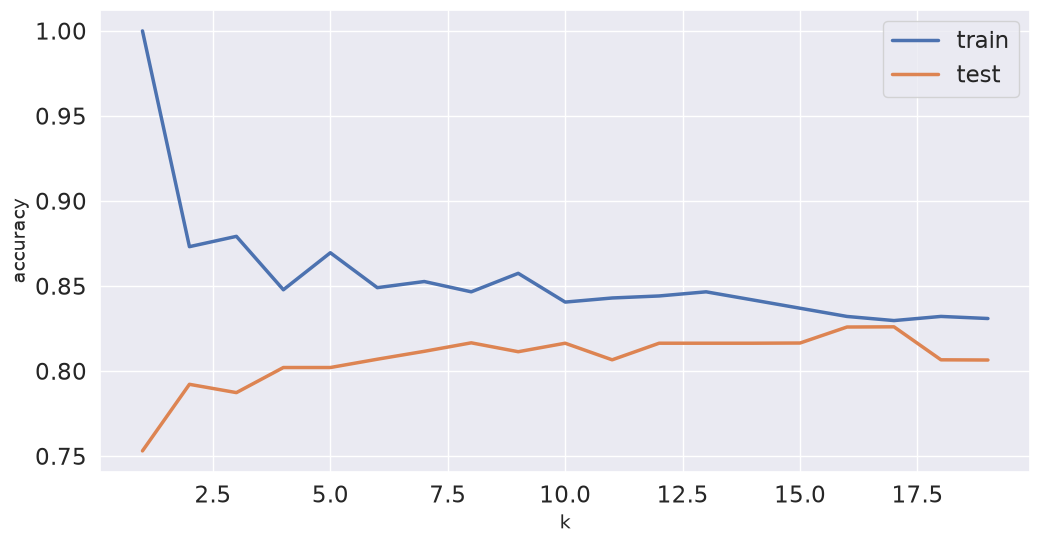

In [27]:
f, ax = plt.subplots(1,1)
ax.plot(range(1, 20), history['train'], label="train")
ax.plot(range(1, 20), history['val'], label="test")
ax.set_xlabel('k', fontsize=14)
ax.set_ylabel('accuracy', fontsize=14)
ax.legend()

### 4 - 4 - Entraînement du meilleur modèle

<strong style="color: #4a86e8">Exercice 4-4: utiliser les résultas précédents pour sélectionner le meilleur modèle, et réentrainer ce modèle sur l'ensemble des données d'entraînement</strong>

In [32]:
# Compléter la fonction ci-dessous ~ quelques lignes ...

# Meilleur modèle = nombre de voisins k ayant la meilleure accuracy moyenne sur les plis de validation
k_best = int(np.argmax(history['val'])) + 1
print(f"Meilleur nombre de voisins k = {k_best}")

# Réentraînement sur l'ensemble du jeu d'entraînement
X_train_scaled = scaler.fit_transform(X_train)
knn = KNeighborsClassifier(n_neighbors=k_best)
knn.fit(X_train_scaled, y_train)

knn.

Meilleur nombre de voisins k = 17


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",17
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 4 - 5 - Performances du meilleur modèle

<strong style="color: #4a86e8">Exercice 4-5: Évaluer les performances du meilleur modèle sur le jeu de test</strong>

In [31]:
# Compléter la fonction ci-dessous ~ quelques lignes ...

X_test_scaled = scaler.transform(X_test)
print(f"Accuracy d'entraînement = {accuracy_score(y_train, knn.predict(X_train_scaled))}")
print(f"Accuracy de test = {accuracy_score(y_test, knn.predict(X_test_scaled))}")

Accuracy d'entraînement = 0.8357487922705314
Accuracy de test = 0.8666666666666667


<strong style="color: #4a86e8">Exercice 4-6: Expliquer ces performances</strong>

**Réponse :**

- Avec `k = 1`, l'accuracy d'entraînement vaut 100 % : chaque observation est son propre plus proche voisin. Le modèle est très flexible et surajuste les données (accuracy de validation ≈ 75 %).
- Quand `k` augmente, le modèle devient moins flexible : l'accuracy d'entraînement diminue et l'accuracy de validation augmente jusqu'à se stabiliser autour de 81-83 % pour `k` entre 8 et 17.
- Le meilleur modèle (`k = 17`) obtient une accuracy de test (≈ 87 %) un peu supérieure à l'accuracy de validation (≈ 83 %). Cet écart n'est pas significatif : le jeu de test ne contient que 90 observations, donc une observation représente ≈ 1,1 % d'accuracy. L'estimation obtenue sur un si petit jeu de test est très variable.

### 5 - Choix du modèle final

<strong style="color: #4a86e8">Exercice 5: Quel modèle choisissez-vous ? Quels sont les valeurs des hyperparamètres ?</strong>

**Réponse :**

Le choix doit se faire à partir des performances sur les plis de validation, **pas** sur le jeu de test. Le jeu de test sert seulement à estimer la performance du modèle final.

| Modèle | Hyperparamètre | Accuracy validation (5 plis) | Accuracy test |
|---|---|---|---|
| Régression logistique polynomiale | `n = 3` | ≈ 0,826 | ≈ 0,833 |
| KNN | `k = 17` | ≈ 0,826 | ≈ 0,867 |

Les deux modèles ont la même accuracy de validation. On peut donc retenir la **régression logistique avec `n = 3`** : elle est plus facilement interprétable (coefficients), plus rapide en prédiction (pas besoin de conserver tout le jeu d'entraînement) et ses performances en validation et en test sont cohérentes. Choisir le KNN parce qu'il a une meilleure accuracy de test reviendrait à utiliser le jeu de test pour sélectionner le modèle.

### Fin de l'atelier

In [ ]:
# thetas

In [34]:
# Ton livrable
def predict(X_nouvelles_donnees_prod_du_client):
    # theta
    # Implemente le model
    # Prediction
    # Retourne les predictions

_IncompleteInputError: incomplete input (1385794742.py, line 2)

In [ ]:
# CLient

In [ ]:
predict(donnes) -> predictions